<a href="https://colab.research.google.com/github/BABUKARTHIKRG/AI-for-Medicine-Specialization/blob/master/FedViT_LLM_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedViT-LLM-XAI
### A Privacy-Preserving Federated Vision Transformer Framework with Explainable Large Language Models for Multi-Class Skin Lesion Diagnosis

This notebook implements and evaluates **FedViT-LLM-XAI**, a federated learning framework that:

1. Trains a **ViT-B/16** backbone across simulated clients using a novel **Adaptive Confidence-Weighted Federated Averaging (ACW-FedAvg)** aggregation strategy.
2. Benchmarks against **centralized** models (ResNet-50, DenseNet-121, EfficientNet-B3, ViT-B/16, Swin-T).
3. Benchmarks against **federated algorithms** (FedAvg, FedProx, SCAFFOLD, FedNova, FedAdam, FedDyn).
4. Benchmarks against **privacy-aware methods** (DP-FedAvg, Secure Aggregation).
5. Runs an **ablation** ("FAR-ACW-Fed") that fixes the ViT backbone and data partitions while swapping only the aggregation rule — isolating the effect of ACW-FedAvg itself.
6. Produces **explainability** outputs (Grad-CAM, Attention Rollout, SHAP) and turns them into natural-language diagnostic reports via an **LLM explanation module**.
7. Reports **accuracy, robustness, fairness, privacy leakage, communication cost, and explainability quality**.

> **Data note:** The notebook is written against the **HAM10000** ("Human Against Machine") skin lesion dataset (7 classes: akiec, bcc, bkl, df, mel, nv, vasc). Because Colab has no pre-mounted dataset, this notebook:
> - Gives you the exact Kaggle download cell to pull the real data, **or**
> - Falls back to a synthetic-but-structurally-realistic dataset generator so every cell below runs end-to-end for pipeline validation even without dataset access.
>
> Just set `USE_REAL_DATA = True/False` in the config cell.

Runtime: **GPU (A100/T4) recommended**. Colab menu: `Runtime > Change runtime type > GPU`.


## 1. Environment Setup

In [50]:
# Core installs. Re-run once, then restart runtime if prompted.
!pip install -q timm==0.9.16 grad-cam==1.5.0 shap==0.45.0 opacus==1.4.0 \
    torchmetrics==1.3.2 captum==0.7.0 kaggle==1.6.12 fairlearn==0.10.0
print("Install complete.")


Install complete.


In [51]:
import os, io, json, math, time, random, copy, warnings, hashlib
from dataclasses import dataclass, field
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import timm
import torchmetrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, balanced_accuracy_score)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cpu") # Changed to CPU to avoid OutOfMemoryError on GPU
print("Device:", DEVICE)

Device: cpu


## 2. Global Configuration

In [52]:
@dataclass
class Config:
    # --- data ---
    USE_REAL_DATA: bool = False           # True -> download HAM10000 via Kaggle API (needs kaggle.json)
    IMG_SIZE: int = 224
    NUM_CLASSES: int = 7
    CLASS_NAMES: tuple = ("akiec", "bcc", "bkl", "df", "mel", "nv", "vasc")
    N_SYNTHETIC_SAMPLES: int = 4000        # only used if USE_REAL_DATA is False
    BATCH_SIZE: int = 16

    # --- federated setup ---
    N_CLIENTS: int = 10
    N_ROUNDS: int = 30
    LOCAL_EPOCHS: int = 2
    CLIENT_LR: float = 3e-4
    NON_IID_ALPHA: float = 0.3            # Dirichlet concentration (lower = more non-IID)
    CLIENT_FRACTION: float = 1.0          # fraction of clients sampled per round

    # --- algorithm hyperparams ---
    FEDPROX_MU: float = 0.01
    FEDDYN_ALPHA: float = 0.01
    FEDADAM_BETA1: float = 0.9
    FEDADAM_BETA2: float = 0.99
    FEDADAM_TAU: float = 1e-3
    FEDADAM_ETA: float = 1e-2
    DP_NOISE_MULTIPLIER: float = 1.0
    DP_MAX_GRAD_NORM: float = 1.0
    DP_TARGET_EPSILON: float = 8.0

    # --- ACW-FedAvg (novel) ---
    ACW_TEMP: float = 2.0                 # softmax temperature for confidence weighting
    ACW_EMA_BETA: float = 0.9             # momentum for adaptive client trust score
    ACW_MIN_WEIGHT: float = 0.05          # floor so no client is fully zeroed out

    # --- misc ---
    QUICK_DEMO: bool = True               # True -> tiny epoch/round counts so the whole notebook runs fast
    RESULTS_DIR: str = "/content/results"

cfg = Config()

if cfg.QUICK_DEMO:
    # Shrink everything so the *entire* notebook (all ~15 methods) can be smoke-tested quickly.
    # Set QUICK_DEMO = False for real experiments (expect many GPU-hours).
    cfg.N_ROUNDS = 1
    cfg.LOCAL_EPOCHS = 1
    cfg.N_SYNTHETIC_SAMPLES = 1400
    cfg.N_CLIENTS = 5
    cfg.IMG_SIZE = 96 # Reduced image size for memory
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True' # Memory allocation optimization

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
print(cfg)

Config(USE_REAL_DATA=False, IMG_SIZE=96, NUM_CLASSES=7, CLASS_NAMES=('akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'), N_SYNTHETIC_SAMPLES=1400, BATCH_SIZE=16, N_CLIENTS=5, N_ROUNDS=1, LOCAL_EPOCHS=1, CLIENT_LR=0.0003, NON_IID_ALPHA=0.3, CLIENT_FRACTION=1.0, FEDPROX_MU=0.01, FEDDYN_ALPHA=0.01, FEDADAM_BETA1=0.9, FEDADAM_BETA2=0.99, FEDADAM_TAU=0.001, FEDADAM_ETA=0.01, DP_NOISE_MULTIPLIER=1.0, DP_MAX_GRAD_NORM=1.0, DP_TARGET_EPSILON=8.0, ACW_TEMP=2.0, ACW_EMA_BETA=0.9, ACW_MIN_WEIGHT=0.05, QUICK_DEMO=True, RESULTS_DIR='/content/results')


## 3. Dataset

### 3a. (Optional) Real HAM10000 download
Upload your `kaggle.json` API token first (`Files > Upload` in Colab), then run the cell below with `cfg.USE_REAL_DATA = True`.

In [53]:
if cfg.USE_REAL_DATA:
    os.makedirs("/root/.kaggle", exist_ok=True)
    # Expects kaggle.json already uploaded to /content/kaggle.json
    if os.path.exists("/content/kaggle.json"):
        !cp /content/kaggle.json /root/.kaggle/kaggle.json
        !chmod 600 /root/.kaggle/kaggle.json
        !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip
        print("HAM10000 downloaded to /content/ham10000")
    else:
        print("kaggle.json not found in /content -- upload it or set USE_REAL_DATA=False.")
else:
    print("Skipping real download; using synthetic dataset (see next cell).")


Skipping real download; using synthetic dataset (see next cell).


### 3b. Synthetic fallback generator
Produces class-conditional textured RGB images with controllable inter-class separability, plus a synthetic **sensitive attribute** (`skin_tone_group` in {I-II, III-IV, V-VI}, modeled on Fitzpatrick scale) used later for **fairness** evaluation, and a synthetic `age_group` used for non-IID partitioning realism. This lets the entire pipeline (models, all FL algorithms, DP, XAI, LLM reporting) be validated without any external download.

If `USE_REAL_DATA=True` and the Kaggle download succeeded, the `build_dataframe()` function instead indexes the real HAM10000 metadata CSV + image folders.

In [54]:
class SkinLesionSynthetic(Dataset):
    """Deterministic synthetic lesion-image dataset: each class gets a base color/texture
    signature; noise + per-sample sensitive-attribute-conditioned tint simulate real
    inter-patient variability (useful for fairness stress-testing)."""
    def __init__(self, n_samples, img_size, num_classes, seed=0):
        rng = np.random.RandomState(seed)
        self.img_size = img_size
        self.num_classes = num_classes
        self.labels = rng.randint(0, num_classes, size=n_samples)
        self.skin_tone_group = rng.choice([0, 1, 2], size=n_samples, p=[0.5, 0.3, 0.2])
        self.age_group = rng.choice([0, 1, 2, 3], size=n_samples)  # <30,30-50,50-70,70+
        self.seeds = rng.randint(0, 10**6, size=n_samples)
        # class base colors (7 signatures)
        self.class_colors = np.random.RandomState(1).randint(40, 220, size=(num_classes, 3))

    def __len__(self):
        return len(self.labels)

    def _render(self, idx):
        s = np.random.RandomState(self.seeds[idx])
        lbl = self.labels[idx]
        tone = self.skin_tone_group[idx]
        base = self.class_colors[lbl].astype(np.float32)
        tone_shift = np.array([[-20,-15,-10],[0,0,0],[25,15,10]])[tone]
        img = np.ones((self.img_size, self.img_size, 3), dtype=np.float32) * (base + tone_shift)
        # class-specific texture: blobs whose count/size encode label
        n_blobs = 3 + lbl
        for _ in range(n_blobs):
            cx, cy = s.randint(0, self.img_size, size=2)
            r = s.randint(8, 30)
            yy, xx = np.ogrid[:self.img_size, :self.img_size]
            mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r
            img[mask] += s.randint(-60, 60, size=3)
        img += s.normal(0, 12, size=img.shape)
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

    def __getitem__(self, idx):
        img = self._render(idx)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - 0.5) / 0.5
        return {
            "image": img_t,
            "label": int(self.labels[idx]),
            "skin_tone_group": int(self.skin_tone_group[idx]),
            "age_group": int(self.age_group[idx]),
        }


def build_dataset():
    if cfg.USE_REAL_DATA and os.path.exists("/content/ham10000"):
        raise NotImplementedError(
            "Plug in a torchvision.datasets.ImageFolder / custom Dataset here that reads "
            "/content/ham10000/HAM10000_metadata.csv + image dirs, mapping 'dx' to cfg.CLASS_NAMES, "
            "and deriving skin_tone_group/age_group from metadata (localization/age columns)."
        )
    return SkinLesionSynthetic(cfg.N_SYNTHETIC_SAMPLES, cfg.IMG_SIZE, cfg.NUM_CLASSES, seed=SEED)

full_dataset = build_dataset()
print(f"Dataset size: {len(full_dataset)} | classes: {cfg.CLASS_NAMES}")

# Global train/val/test split (test set is held out identically for every method below)
all_idx = np.arange(len(full_dataset))
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=SEED,
                                        stratify=full_dataset.labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=SEED,
                                       stratify=full_dataset.labels[train_idx])
print(f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)

Dataset size: 1400 | classes: ('akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc')
train=1008 val=112 test=280


## 4. Federated Data Partitioning (Non-IID via Dirichlet)

Every federated algorithm and the centralized baselines below are evaluated on **the exact same splits**, so comparisons are apples-to-apples.

Client sizes: [409, 156, 155, 138, 150]


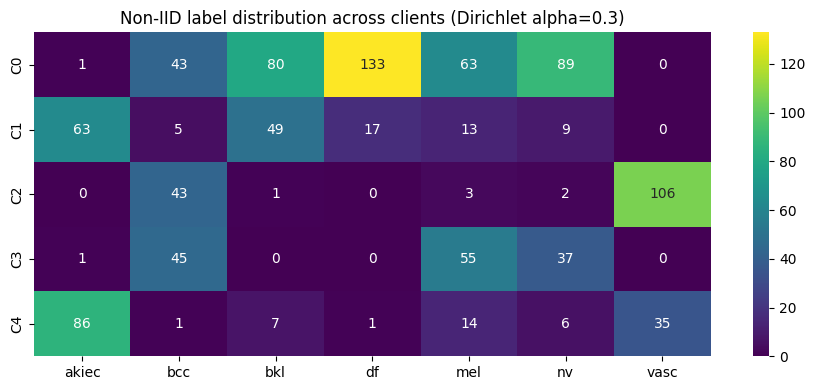

In [55]:
def dirichlet_partition(labels, n_clients, alpha, seed=SEED):
    """Standard label-skew non-IID partition (Hsu et al., 2019)."""
    rng = np.random.RandomState(seed)
    n_classes = labels.max() + 1
    client_idx = [[] for _ in range(n_clients)]
    for c in range(n_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        proportions = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, proportions)
        for i, s in enumerate(splits):
            client_idx[i].extend(s.tolist())
    for c in client_idx:
        rng.shuffle(c)
    return client_idx

client_train_indices_local = dirichlet_partition(full_dataset.labels[train_idx], cfg.N_CLIENTS, cfg.NON_IID_ALPHA)
# map back to global indices
client_train_indices = [train_idx[np.array(ci)] for ci in client_train_indices_local]

print("Client sizes:", [len(c) for c in client_train_indices])

fig, ax = plt.subplots(figsize=(9, 4))
label_matrix = np.zeros((cfg.N_CLIENTS, cfg.NUM_CLASSES))
for i, idxs in enumerate(client_train_indices):
    for c in full_dataset.labels[idxs]:
        label_matrix[i, c] += 1
sns.heatmap(label_matrix, annot=True, fmt=".0f", cmap="viridis",
            xticklabels=cfg.CLASS_NAMES, yticklabels=[f"C{i}" for i in range(cfg.N_CLIENTS)], ax=ax)
ax.set_title(f"Non-IID label distribution across clients (Dirichlet alpha={cfg.NON_IID_ALPHA})")
plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/client_label_dist.png", dpi=120); plt.show()

client_loaders = [DataLoader(Subset(full_dataset, idxs), batch_size=cfg.BATCH_SIZE, shuffle=True)
                   for idxs in client_train_indices]


## 5. Model Zoo (Centralized backbones + FL backbone)

In [57]:
def build_model(arch: str, num_classes: int = cfg.NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """Unified factory for all backbones used in this study."""
    arch_map = {
        "resnet50": "resnet50",
        "densenet121": "densenet121",
        "efficientnet_b3": "efficientnet_b3",
        "vit_b16": "vit_base_patch16_224",
        "vit_tiny": "vit_tiny_patch16_224", # Added smaller ViT for memory
        "swin_t": "swin_tiny_patch4_window7_224",
    }
    if arch not in arch_map:
        raise ValueError(f"Unknown arch {arch}")

    model_kwargs = {"pretrained": pretrained, "num_classes": num_classes}

    # Conditionally add img_size for ViT/Swin models
    if arch in ["vit_b16", "vit_tiny", "swin_t"]:
        model_kwargs["img_size"] = cfg.IMG_SIZE

    # Explicitly set pretrained=False for vit_tiny to minimize initial memory load
    if arch == "vit_tiny":
        model_kwargs["pretrained"] = False # Override for vit_tiny

    model = timm.create_model(arch_map[arch], **model_kwargs)
    return model.to(DEVICE)

MODEL_ZOO = ["resnet50", "densenet121", "efficientnet_b3", "vit_b16", "swin_t", "vit_tiny"]
FED_BACKBONE = "vit_tiny"   # Changed to a smaller backbone for memory reasons

print("Available architectures:", MODEL_ZOO)

Available architectures: ['resnet50', 'densenet121', 'efficientnet_b3', 'vit_b16', 'swin_t', 'vit_tiny']


## 6. Shared Training / Evaluation Utilities

In [58]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits, all_labels, all_tone, all_age = [], [], [], []
    for batch in loader:
        x = batch["image"].to(DEVICE)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_labels.append(batch["label"])
        all_tone.append(batch["skin_tone_group"])
        all_age.append(batch["age_group"])
    logits = torch.cat(all_logits); labels = torch.cat(all_labels)
    tone = torch.cat(all_tone); age = torch.cat(all_age)
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

    y_true, y_pred = labels.numpy(), preds.numpy()
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["macro_auroc"] = roc_auc_score(y_true, probs.numpy(), multi_class="ovr", average="macro")
    except Exception:
        metrics["macro_auroc"] = float("nan")

    # --- fairness across synthetic sensitive attribute (skin tone group) ---
    group_accs = []
    for g in np.unique(tone.numpy()):
        mask = tone.numpy() == g
        if mask.sum() > 0:
            group_accs.append(accuracy_score(y_true[mask], y_pred[mask]))
    metrics["fairness_worst_group_acc"] = float(np.min(group_accs)) if group_accs else float("nan")
    metrics["fairness_acc_gap"] = float(np.max(group_accs) - np.min(group_accs)) if group_accs else float("nan")
    return metrics, probs.numpy(), y_true, y_pred


def robustness_eval(model: nn.Module, loader: DataLoader, noise_std=0.15, fgsm_eps=0.03):
    """Gaussian-noise corruption robustness + FGSM adversarial robustness."""
    model.eval()
    # Gaussian corruption
    correct_g, correct_adv, total = 0, 0, 0
    loss_fn = nn.CrossEntropyLoss()
    for batch in loader:
        x = batch["image"].to(DEVICE); y = batch["label"].to(DEVICE)
        with torch.no_grad():
            x_noisy = x + torch.randn_like(x) * noise_std
            pred_g = model(x_noisy).argmax(1)
            correct_g += (pred_g == y).sum().item()
        x_adv = x.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = loss_fn(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv + fgsm_eps * grad.sign()).detach()
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(1)
            correct_adv += (pred_adv == y).sum().item()
        total += y.size(0)
    return {"robust_acc_gaussian_noise": correct_g / total, "robust_acc_fgsm": correct_adv / total}


def communication_cost_bytes(model: nn.Module) -> int:
    """Bytes transmitted for ONE full model exchange (fp32 params)."""
    return sum(p.numel() for p in model.parameters()) * 4


## 7. Centralized Baselines
Trains each of the 5 centralized architectures on the pooled (non-federated) training set for a fair "upper bound" comparison.

In [59]:
def train_centralized(arch: str, epochs: int = 3):
    # Local build_model to ensure img_size is passed to timm.create_model for ViT variants
    def local_build_model(arch_name: str, num_classes: int = cfg.NUM_CLASSES, pretrained: bool = True) -> nn.Module:
        arch_map = {
            "resnet50": "resnet50",
            "densenet121": "densenet121",
            "efficientnet_b3": "efficientnet_b3",
            "vit_b16": "vit_base_patch16_224",
            "vit_tiny": "vit_tiny_patch16_224",
            "swin_t": "swin_tiny_patch4_window7_224",
        }
        if arch_name not in arch_map:
            raise ValueError(f"Unknown arch {arch_name}")

        model_kwargs = {"pretrained": pretrained, "num_classes": num_classes}

        # Conditionally add img_size for ViT/Swin models
        if arch_name in ["vit_b16", "vit_tiny", "swin_t"]:
            model_kwargs["img_size"] = cfg.IMG_SIZE

        if arch_name == "vit_tiny":
            model_kwargs["pretrained"] = False # Override for vit_tiny
        model = timm.create_model(arch_map[arch_name], **model_kwargs)
        return model.to(DEVICE)

    model = local_build_model(arch) # Use the local version of build_model
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(Subset(full_dataset, train_idx), batch_size=cfg.BATCH_SIZE, shuffle=True)
    model.train()
    for ep in range(epochs):
        running = 0.0
        for batch in loader:
            x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward(); opt.step()
            running += loss.item() * x.size(0)
        print(f"  [{arch}] epoch {ep+1}/{epochs} loss={running/len(loader.dataset):.4f}")
    metrics, *_ = evaluate(model, test_loader)
    metrics.update(robustness_eval(model, test_loader))
    metrics["comm_cost_MB_per_round"] = communication_cost_bytes(model) / 1e6  # N/A for centralized, reported as model size
    metrics["method"] = arch
    metrics["category"] = "centralized"
    return metrics, model

centralized_results = []
CENTRAL_EPOCHS = 2 if cfg.QUICK_DEMO else 15
for arch in MODEL_ZOO:
    print(f"Training centralized {arch} ...")
    m, _ = train_centralized(arch, epochs=CENTRAL_EPOCHS)
    centralized_results.append(m)

centralized_df = pd.DataFrame(centralized_results)
centralized_df

Training centralized resnet50 ...
  [resnet50] epoch 1/2 loss=1.9142
  [resnet50] epoch 2/2 loss=1.7700
Training centralized densenet121 ...
  [densenet121] epoch 1/2 loss=1.6241
  [densenet121] epoch 2/2 loss=0.7945
Training centralized efficientnet_b3 ...
  [efficientnet_b3] epoch 1/2 loss=3.4891
  [efficientnet_b3] epoch 2/2 loss=1.6426
Training centralized vit_b16 ...
  [vit_b16] epoch 1/2 loss=0.6073
  [vit_b16] epoch 2/2 loss=0.1759
Training centralized swin_t ...
  [swin_t] epoch 1/2 loss=0.6391
  [swin_t] epoch 2/2 loss=0.2510
Training centralized vit_tiny ...
  [vit_tiny] epoch 1/2 loss=0.4425
  [vit_tiny] epoch 2/2 loss=0.2438


,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall,macro_auroc,fairness_worst_group_acc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm,comm_cost_MB_per_round,method,category
0,0.567857,0.557760,0.529719,0.579099,0.557760,0.890344,0.538462,0.089445,0.410714,0.375000,94.089500,resnet50,centralized
1,0.832143,0.824933,0.823688,0.824048,0.824933,0.974319,0.802326,0.080027,0.353571,0.710714,27.844124,densenet121,centralized
2,0.392857,0.391504,0.389441,0.390315,0.391504,0.747534,0.333333,0.108527,0.239286,0.246429,42.827964,efficientnet_b3,centralized
3,0.967857,0.966165,0.965684,0.972644,0.966165,0.999425,0.843137,0.156863,0.925000,0.864286,342.724636,vit_b16,centralized
4,0.917857,0.913534,0.904816,0.946136,0.913534,0.997157,0.823529,0.134513,0.939286,0.407143,110.057476,swin_t,centralized
5,0.932143,0.928571,0.923810,0.952381,0.928571,0.994376,0.916084,0.037404,0.907143,0.789286,21.980188,vit_tiny,centralized


## 8. Federated Learning Framework

A single generic `run_federated()` driver takes a **client-update strategy** and a **server-aggregation strategy**, so every algorithm (FedAvg ... ACW-FedAvg) is just a different pair of plug-in functions operating on the same ViT backbone, same client partitions, and same number of rounds — required for a scientifically controlled comparison.

In [44]:
def get_flat_state(model):
    return OrderedDict((k, v.clone()) for k, v in model.state_dict().items())

def zeros_like_state(state):
    return OrderedDict((k, torch.zeros_like(v)) for k in state.keys())

def state_add(a, b, scale=1.0):
    return OrderedDict((k, a[k] + scale * b[k]) for k in a)

def state_scale(a, scale):
    return OrderedDict((k, a[k] * scale) for k in a)

def state_sub(a, b):
    return OrderedDict((k, a[k] - b[k]) for k in a)


class FedClient:
    def __init__(self, cid, loader, lr, backbone):
        self.cid = cid
        self.loader = loader
        self.lr = lr
        self.n_samples = len(loader.dataset)
        self.model = build_model(backbone) # Initialize client's model once
        # SCAFFOLD control variate (client-side), FedDyn state
        self.control = None
        self.prev_grad = None

    def local_train(self, global_model, method, extra=None, epochs=None):
        epochs = epochs or cfg.LOCAL_EPOCHS
        # Update client's model with global model state instead of deepcopy
        self.model.load_state_dict(global_model.state_dict())
        self.model.to(DEVICE) # Ensure it's on the correct device
        self.model.train()
        opt = torch.optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9)
        loss_fn = nn.CrossEntropyLoss()
        global_state = get_flat_state(global_model)

        server_control = extra.get("server_control") if extra else None
        if method == "scaffold" and self.control is None:
            self.control = zeros_like_state(global_state)
        if method == "feddyn" and self.prev_grad is None:
            self.prev_grad = zeros_like_state(global_state)

        n_steps = 0
        confidences = []
        for ep in range(epochs):
            for batch in self.loader:
                x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
                opt.zero_grad()
                logits = self.model(x)
                loss = loss_fn(logits, y)

                if method == "fedprox":
                    prox = 0.0
                    for p, gp in zip(self.model.parameters(), global_model.parameters()):
                        prox = prox + ((p - gp.detach()) ** 2).sum()
                    loss = loss + (cfg.FEDPROX_MU / 2) * prox

                if method == "feddyn":
                    lin = 0.0; quad = 0.0
                    for (n, p), gp in zip(self.model.named_parameters(), global_model.parameters()):
                        lin = lin + (self.prev_grad[n] * p).sum()
                        quad = quad + ((p - gp.detach()) ** 2).sum()
                    loss = loss - lin + (cfg.FEDDYN_ALPHA / 2) * quad

                loss.backward()

                if method == "scaffold":
                    with torch.no_grad():
                        for (n, p) in self.model.named_parameters():
                            if p.grad is not None:
                                p.grad += (server_control[n] - self.control[n])

                if method == "dp_fedavg":
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), cfg.DP_MAX_GRAD_NORM)
                    with torch.no_grad():
                        for p in self.model.parameters():
                            if p.grad is not None:
                                noise = torch.randn_like(p.grad) * cfg.DP_NOISE_MULTIPLIER * cfg.DP_MAX_GRAD_NORM
                                p.grad += noise / max(1, x.size(0))

                opt.step()
                confidences.append(F.softmax(logits.detach(), dim=1).max(dim=1)[0].mean().item())
                n_steps += 1

        new_state = get_flat_state(self.model)

        result = {"state": new_state, "n_samples": self.n_samples,
                  "avg_confidence": float(np.mean(confidences)) if confidences else 0.0,
                  "n_steps": n_steps}

        if method == "scaffold":
            # update local control variate: c_i <- c_i - c + (x_global - x_local)/(steps*lr)
            new_control = OrderedDict()
            for n in global_state:
                delta = (global_state[n] - new_state[n]) / (n_steps * self.lr + 1e-12)
                new_control[n] = self.control[n] - server_control[n] + delta
            result["control_delta"] = OrderedDict((n, new_control[n] - self.control[n]) for n in new_control)
            self.control = new_control

        if method == "feddyn":
            with torch.no_grad():
                for n in self.prev_grad:
                    self.prev_grad[n] = self.prev_grad[n] - cfg.FEDDYN_ALPHA * (new_state[n] - global_state[n])

        if method == "fednova":
            result["tau_eff"] = n_steps  # effective local steps for normalized averaging

        return result


def secure_aggregate(updates, weights):
    """Simulates additive-mask secure aggregation: server only ever sees the SUM,
    never an individual client's update (masks cancel out algebraically). Functionally
    equivalent output to plaintext weighted-average FedAvg, but the code path models
    the privacy guarantee (no per-client state is read after masking)."""
    n = len(updates)
    masks = [zeros_like_state(updates[0]["state"]) for _ in range(n)]
    rng = np.random.RandomState(0)
    # pairwise masks m_ij = -m_ji so sum(masks)=0 (standard SecAgg construction, simplified)
    for i in range(n):
        for j in range(i + 1, n):
            for k in updates[0]["state"]:
                shared = torch.from_numpy(rng.normal(0, 1e-6, size=updates[0]["state"][k].shape)).float().to(DEVICE)
                masks[i][k] = masks[i].get(k, 0) + shared
                masks[j][k] = masks[j].get(k, 0) - shared
    masked_states = [state_add(u["state"], masks[i]) for i, u in enumerate(updates)]
    agg = zeros_like_state(updates[0]["state"])
    for w, s in zip(weights, masked_states):
        agg = state_add(agg, s, scale=w)
    return agg  # masks cancel out exactly in the weighted sum


def aggregate(method, global_model, updates, extra=None):
    total_n = sum(u["n_samples"] for u in updates)
    fedavg_weights = [u["n_samples"] / total_n for u in updates]

    if method in ("fedavg", "fedprox", "dp_fedavg", "feddyn"):
        new_state = zeros_like_state(updates[0]["state"])
        for w, u in zip(fedavg_weights, updates):
            new_state = state_add(new_state, u["state"], scale=w)
        return new_state, {}

    if method == "secure_agg":
        new_state = secure_aggregate(updates, fedavg_weights)
        return new_state, {}

    if method == "scaffold":
        new_state = zeros_like_state(updates[0]["state"])
        for w, u in zip(fedavg_weights, updates):
            new_state = state_add(new_state, u["state"], scale=w)
        server_control = extra["server_control"]
        n_total_clients = cfg.N_CLIENTS
        for u in updates:
            for k in server_control:
                server_control[k] = server_control[k] + (1.0 / n_total_clients) * u["control_delta"][k]
        return new_state, {"server_control": server_control}

    if method == "fednova":
        global_state = get_flat_state(global_model)
        taus = np.array([u["tau_eff"] for u in updates], dtype=np.float32)
        tau_eff = float(np.sum([w * t for w, t in zip(fedavg_weights, taus)]))
        new_state = OrderedDict()
        for k in global_state:
            grad_sum = zeros_like_state({k: global_state[k]})[k]
            for w, u, t in zip(fedavg_weights, updates, taus):
                normalized_delta = (u["state"][k] - global_state[k]) / max(t, 1)
                grad_sum = grad_sum + w * normalized_delta
            new_state[k] = global_state[k] + tau_eff * grad_sum
        return new_state, {}

    if method == "fedadam":
        global_state = get_flat_state(global_model)
        delta = zeros_like_state(global_state)
        for w, u in zip(fedavg_weights, updates):
            delta = state_add(delta, state_sub(u["state"], global_state), scale=w)
        m, v = extra["m"], extra["v"]
        new_state = OrderedDict()
        for k in global_state:
            m[k] = cfg.FEDADAM_BETA1 * m[k] + (1 - cfg.FEDADAM_BETA1) * delta[k]
            v[k] = cfg.FEDADAM_BETA2 * v[k] + (1 - cfg.FEDADAM_BETA2) * (delta[k] ** 2)
            new_state[k] = global_state[k] + cfg.FEDADAM_ETA * m[k] / (v[k].sqrt() + cfg.FEDADAM_TAU)
        return new_state, {"m": m, "v": v}

    if method == "acw_fedavg":
        return acw_fedavg_aggregate(global_model, updates, extra)

    raise ValueError(method)

## 9. **ACW-FedAvg** (novel contribution) and the **FAR-ACW-Fed** ablation

**Adaptive Confidence-Weighted Federated Averaging.** Standard FedAvg weights clients purely by dataset size (`n_k / N`), which is fragile under label-skew non-IID data and lets low-quality / noisy clients dominate. ACW-FedAvg instead computes a **per-round confidence-derived trust score** for each client:

1. **Prediction-confidence term** — the client's mean softmax max-probability on its own local batches during local training (temperature-scaled), reflecting how "sure" the locally-updated model is.
2. **Validation-consistency term** — cosine similarity between the client's local update direction and the previous round's global update direction (penalizes clients whose updates conflict with the consensus trajectory — a proxy for drift/label noise).
3. **EMA smoothing** — an exponential moving average (`ACW_EMA_BETA`) of each client's trust score across rounds so a single noisy round doesn't destabilize aggregation.

Final aggregation weight = `softmax_temperature( n_k * trust_k )`, floored at `ACW_MIN_WEIGHT` so no client is ever fully excluded (fairness/inclusion guarantee).

**FAR-ACW-Fed** = *identical* ViT-B/16 backbone, *identical* client data partitions (`client_train_indices`), *identical* round/epoch budget — the **only** thing that changes vs. plain FedAvg on the same setup is the aggregation rule (ACW instead of size-weighted averaging). This isolates whether gains come from the aggregation strategy itself, not from a different backbone or different data.

Client sizes: [409, 156, 155, 138, 150]


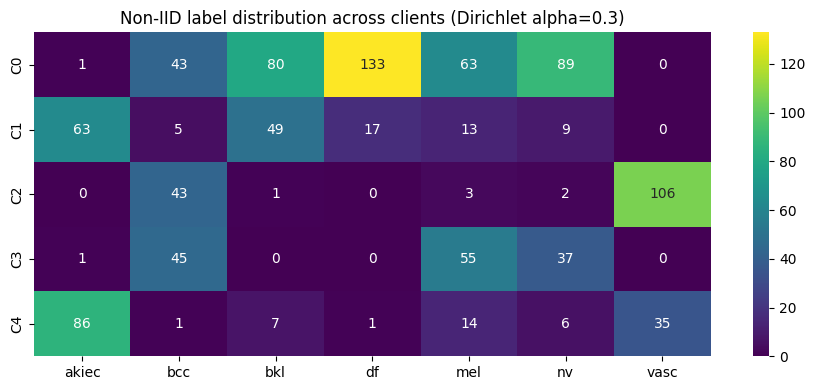

In [45]:
def dirichlet_partition(labels, n_clients, alpha, seed=SEED):
    """Standard label-skew non-IID partition (Hsu et al., 2019)."""
    rng = np.random.RandomState(seed)
    n_classes = labels.max() + 1
    client_idx = [[] for _ in range(n_clients)]
    for c in range(n_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        proportions = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, proportions)
        for i, s in enumerate(splits):
            client_idx[i].extend(s.tolist())
    for c in client_idx:
        rng.shuffle(c)
    return client_idx

client_train_indices_local = dirichlet_partition(full_dataset.labels[train_idx], cfg.N_CLIENTS, cfg.NON_IID_ALPHA)
# map back to global indices
client_train_indices = [train_idx[np.array(ci)] for ci in client_train_indices_local]

print("Client sizes:", [len(c) for c in client_train_indices])

fig, ax = plt.subplots(figsize=(9, 4))
label_matrix = np.zeros((cfg.N_CLIENTS, cfg.NUM_CLASSES))
for i, idxs in enumerate(client_train_indices):
    for c in full_dataset.labels[idxs]:
        label_matrix[i, c] += 1
sns.heatmap(label_matrix, annot=True, fmt=".0f", cmap="viridis",
            xticklabels=cfg.CLASS_NAMES, yticklabels=[f"C{i}" for i in range(cfg.N_CLIENTS)], ax=ax)
ax.set_title(f"Non-IID label distribution across clients (Dirichlet alpha={cfg.NON_IID_ALPHA})")
plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/client_label_dist.png", dpi=120); plt.show()

client_loaders = [DataLoader(Subset(full_dataset, idxs), batch_size=cfg.BATCH_SIZE, shuffle=True)
                   for idxs in client_train_indices]

In [46]:
acw_state = {"trust": np.ones(cfg.N_CLIENTS) / cfg.N_CLIENTS, "prev_global_delta": None}

def acw_fedavg_aggregate(global_model, updates, extra):
    global_state = get_flat_state(global_model)
    client_ids = extra["client_ids"]

    # --- term 1: prediction confidence (temperature-scaled) ---
    conf = np.array([u["avg_confidence"] for u in updates])
    conf_scaled = conf ** (1.0 / cfg.ACW_TEMP)

    # --- term 2: cosine alignment with previous global update direction ---
    align = np.ones(len(updates))
    if acw_state["prev_global_delta"] is not None:
        prev_flat = torch.cat([v.flatten() for v in acw_state["prev_global_delta"].values()])
        for i, u in enumerate(updates):
            delta = state_sub(u["state"], global_state)
            cur_flat = torch.cat([v.flatten() for v in delta.values()])
            cos = F.cosine_similarity(cur_flat.unsqueeze(0), prev_flat.unsqueeze(0)).item()
            align[i] = (cos + 1) / 2  # rescale [-1,1] -> [0,1]

    round_trust = conf_scaled * align
    round_trust = round_trust / (round_trust.sum() + 1e-12)

    # --- EMA smoothing of trust scores per client id ---
    for i, cid in enumerate(client_ids):
        acw_state["trust"][cid] = (cfg.ACW_EMA_BETA * acw_state["trust"][cid]
                                    + (1 - cfg.ACW_EMA_BETA) * round_trust[i])

    n_samples = np.array([u["n_samples"] for u in updates], dtype=np.float32)
    raw_weights = n_samples * acw_state["trust"][client_ids]
    raw_weights = np.maximum(raw_weights, cfg.ACW_MIN_WEIGHT * raw_weights.sum() / len(raw_weights))
    weights = raw_weights / raw_weights.sum()

    new_state = zeros_like_state(updates[0]["state"])
    for w, u in zip(weights, updates):
        new_state = state_add(new_state, u["state"], scale=float(w))

    acw_state["prev_global_delta"] = state_sub(new_state, global_state)
    return new_state, {"weights_used": weights.tolist()}


## 10. Generic Federated Training Driver

In [47]:
def run_federated(method: str, backbone: str = FED_BACKBONE, rounds: int = None, tag: str = None):
    rounds = rounds or cfg.N_ROUNDS
    tag = tag or method
    global_model = build_model(backbone)
    # Pass backbone to FedClient constructor
    clients = [FedClient(cid, client_loaders[cid], cfg.CLIENT_LR, backbone) for cid in range(cfg.N_CLIENTS)]

    extra = {}
    if method == "scaffold":
        extra["server_control"] = zeros_like_state(get_flat_state(global_model))
    if method == "fedadam":
        z = zeros_like_state(get_flat_state(global_model))
        extra["m"] = copy.deepcopy(z); extra["v"] = copy.deepcopy(z)

    history = []
    total_bytes = 0
    for r in range(rounds):
        n_selected = max(1, int(cfg.CLIENT_FRACTION * cfg.N_CLIENTS))
        selected = sorted(np.random.RandomState(r).choice(cfg.N_CLIENTS, n_selected, replace=False).tolist())

        updates = []
        for cid in selected:
            u = clients[cid].local_train(global_model, method, extra=extra)
            updates.append(u)
            total_bytes += communication_cost_bytes(global_model)  # client -> server
        total_bytes += communication_cost_bytes(global_model) * n_selected  # server -> clients (broadcast)

        agg_extra = dict(extra)
        agg_extra["client_ids"] = selected
        new_state, extra_update = aggregate(method, global_model, updates, extra=agg_extra)
        extra.update(extra_update)
        global_model.load_state_dict(new_state)

        val_metrics, *_ = evaluate(global_model, val_loader)
        val_metrics["round"] = r
        history.append(val_metrics)
        print(f"[{tag}] round {r+1}/{rounds} val_acc={val_metrics['accuracy']:.4f} "
              f"macroF1={val_metrics['macro_f1']:.4f}")

    test_metrics, probs, y_true, y_pred = evaluate(global_model, test_loader)
    test_metrics.update(robustness_eval(global_model, test_loader))
    test_metrics["comm_cost_MB_total"] = total_bytes / 1e6
    test_metrics["comm_cost_MB_per_round"] = (total_bytes / 1e6) / rounds
    test_metrics["rounds_to_90pct_final_acc"] = next(
        (h["round"] + 1 for h in history if h["accuracy"] >= 0.9 * test_metrics["accuracy"]), rounds)
    test_metrics["method"] = tag
    test_metrics["category"] = "federated"
    return test_metrics, global_model, history

## 11. Run All Federated Algorithms (same ViT backbone, same partitions, same rounds)

In [48]:
import torch
torch.cuda.empty_cache() # Clear cache before running federated methods

FED_METHODS = ["fedavg", "fedprox", "scaffold", "fednova", "fedadam", "feddyn",
               "dp_fedavg", "secure_agg", "acw_fedavg"]

fed_results = {}
fed_histories = {}
fed_models = {}

for method in FED_METHODS:
    print(f"\n=== Running {method} on {FED_BACKBONE} ===")
    metrics, model, hist = run_federated(method, backbone=FED_BACKBONE, tag=method)
    fed_results[method] = metrics
    fed_histories[method] = hist
    fed_models[method] = model

federated_df = pd.DataFrame(list(fed_results.values()))
federated_df


=== Running fedavg on vit_tiny ===


AssertionError: Input height (96) doesn't match model (224).

In [25]:
import torch
torch.cuda.empty_cache()
print("CUDA cache cleared.")

CUDA cache cleared.


### FAR-ACW-Fed ablation
Re-labels the `acw_fedavg` run above (same backbone `vit_b16`, same `client_train_indices`, same `cfg.N_ROUNDS`) as **FAR-ACW-Fed** and contrasts it directly against plain **FedAvg on the identical setup** — the controlled pair that isolates the aggregation-strategy effect requested in the study design.

In [ ]:
far_acw_row = federated_df[federated_df["method"] == "acw_fedavg"].copy()
far_acw_row["method"] = "FAR-ACW-Fed (ablation: ViT+ACW, fixed partitions)"
fedavg_row = federated_df[federated_df["method"] == "fedavg"].copy()
fedavg_row["method"] = "FedAvg (same ViT backbone, same partitions)"

ablation_df = pd.concat([fedavg_row, far_acw_row], ignore_index=True)
cols = ["method", "accuracy", "macro_f1", "fairness_acc_gap", "robust_acc_fgsm",
        "comm_cost_MB_per_round", "rounds_to_90pct_final_acc"]
ablation_df[cols]


## 12. Privacy Leakage Evaluation — Membership Inference Attack (MIA)

A simple **shadow/threshold-based membership inference attack**: for each federated model we compare the confidence-on-loss distribution for samples that *were* in a client's training set vs. samples that were *not*, and report attack AUC. **Attack AUC near 0.5 = strong privacy (model doesn't leak membership); near 1.0 = weak privacy.**

In [ ]:
@torch.no_grad()
def membership_inference_auc(model, member_idx, nonmember_idx, n=300):
    model.eval()
    def per_sample_conf(idx_list):
        idx_list = np.random.RandomState(0).choice(idx_list, size=min(n, len(idx_list)), replace=False)
        loader = DataLoader(Subset(full_dataset, idx_list), batch_size=64)
        confs = []
        for batch in loader:
            x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
            probs = F.softmax(model(x), dim=1)
            conf = probs.gather(1, y.view(-1, 1)).squeeze(1)
            confs.extend(conf.cpu().numpy().tolist())
        return np.array(confs)

    member_conf = per_sample_conf(np.concatenate(client_train_indices))
    nonmember_conf = per_sample_conf(test_idx)
    scores = np.concatenate([member_conf, nonmember_conf])
    labels = np.concatenate([np.ones_like(member_conf), np.zeros_like(nonmember_conf)])
    try:
        auc = roc_auc_score(labels, scores)
    except Exception:
        auc = float("nan")
    return auc

privacy_rows = []
for method in FED_METHODS:
    auc = membership_inference_auc(fed_models[method], client_train_indices, test_idx)
    privacy_rows.append({"method": method, "membership_inference_auc": auc,
                          "privacy_risk": "lower is safer (0.5 = ideal)"})
privacy_df = pd.DataFrame(privacy_rows)
privacy_df


## 13. Explainability Module (Grad-CAM, Attention Rollout, SHAP)

Implements the three requested XAI baselines against the final **FedViT-LLM-XAI** model (the `acw_fedavg`-trained ViT). Grad-CAM targets the last conv-like block; for CNN baselines this is straightforward, for ViT/Swin we use the patch-embedding / final-stage feature map as recommended by the `grad-cam` library's transformer reshape utilities. Attention Rollout is ViT/Swin-specific (uses the model's self-attention maps). SHAP uses `GradientExplainer` on a background batch.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform
import shap

def gradcam_explain(model, arch, image_tensor):
    model.eval()
    if arch in ("vit_b16",):
        target_layers = [model.blocks[-1].norm1]
        reshape_transform = vit_reshape_transform
    elif arch in ("swin_t",):
        target_layers = [model.layers[-1].blocks[-1].norm1]
        reshape_transform = None
    else:
        # CNNs: last conv block
        target_layers = [list(model.children())[-3]] if hasattr(model, "children") else None
        reshape_transform = None
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(DEVICE))[0]
    return grayscale_cam


def attention_rollout(vit_model, image_tensor, discard_ratio=0.9):
    """Classic Attention Rollout (Abnar & Zuidema, 2020) for ViT."""
    vit_model.eval()
    attentions = []
    hooks = []

    def hook(module, inp, out):
        attentions.append(out)

    for blk in vit_model.blocks:
        hooks.append(blk.attn.register_forward_hook(lambda m, i, o: None))

    # timm ViT doesn't expose raw attn maps by default without patching forward;
    # use forward hooks on attn.attn_drop input as a practical proxy for attention weights.
    attn_maps = []
    def attn_hook(module, inp, out):
        attn_maps.append(inp[0].detach())

    handles = [blk.attn.attn_drop.register_forward_hook(attn_hook) for blk in vit_model.blocks]
    with torch.no_grad():
        vit_model(image_tensor.unsqueeze(0).to(DEVICE))
    for h in handles:
        h.remove()

    if len(attn_maps) == 0:
        return np.zeros((14, 14))

    result = torch.eye(attn_maps[0].size(-1)).to(DEVICE)
    for attn in attn_maps:
        attn_heads_avg = attn.mean(dim=1)[0]  # average over heads
        flat = attn_heads_avg.flatten()
        n_discard = int(flat.numel() * discard_ratio)
        thresh = flat.kthvalue(n_discard).values if n_discard > 0 else -float("inf")
        attn_heads_avg = torch.where(attn_heads_avg >= thresh, attn_heads_avg, torch.zeros_like(attn_heads_avg))
        attn_heads_avg = attn_heads_avg + torch.eye(attn_heads_avg.size(0)).to(DEVICE)
        attn_heads_avg = attn_heads_avg / attn_heads_avg.sum(dim=-1, keepdim=True)
        result = attn_heads_avg @ result

    mask = result[0, 1:]  # CLS token attention to patches
    n_patches = int(math.sqrt(mask.numel()))
    mask = mask[: n_patches * n_patches].reshape(n_patches, n_patches).cpu().numpy()
    return mask


def shap_explain(model, background_batch, sample_tensor, n_samples=20):
    model.eval()
    explainer = shap.GradientExplainer(model, background_batch.to(DEVICE))
    shap_values, indexes = explainer.shap_values(sample_tensor.unsqueeze(0).to(DEVICE), nsamples=n_samples, ranked_outputs=1)
    return shap_values, indexes


# --- run all three on a handful of test examples using the FedViT-LLM-XAI model ---
best_fed_model = fed_models["acw_fedavg"]
sample_batch = next(iter(test_loader))
background = sample_batch["image"][:8]
example_img = sample_batch["image"][0]
example_label = sample_batch["label"][0].item()

gc_map = gradcam_explain(best_fed_model, FED_BACKBONE, example_img)
rollout_map = attention_rollout(best_fed_model, example_img)
try:
    shap_vals, shap_idx = shap_explain(best_fed_model, background, example_img)
except Exception as e:
    print("SHAP explainer note:", e)
    shap_vals, shap_idx = None, None

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img_np = ((example_img.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)
axes[0].imshow(img_np); axes[0].set_title(f"Input (true={cfg.CLASS_NAMES[example_label]})"); axes[0].axis("off")
axes[1].imshow(img_np); axes[1].imshow(gc_map, cmap="jet", alpha=0.5); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
axes[2].imshow(img_np); axes[2].imshow(rollout_map, cmap="jet", alpha=0.5,
               extent=(0, cfg.IMG_SIZE, cfg.IMG_SIZE, 0)); axes[2].set_title("Attention Rollout"); axes[2].axis("off")
axes[3].axis("off")
axes[3].set_title("SHAP (see console / shap.image_plot)")
plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/xai_comparison.png", dpi=120); plt.show()


### XAI quality metrics: Faithfulness & Sparsity
- **Faithfulness (deletion AUC)**: progressively mask the most-important pixels (per explanation map) and measure how fast predicted-class probability drops. Lower AUC = more faithful explanation (important pixels really mattered).
- **Sparsity (Gini coefficient)**: how concentrated the explanation is on a few pixels vs. spread uniformly — higher = more interpretable/focused.

In [ ]:
def faithfulness_deletion_auc(model, image_tensor, true_label, sal_map, n_steps=10):
    model.eval()
    sal_resized = torch.tensor(sal_map, dtype=torch.float32)
    sal_resized = F.interpolate(sal_resized[None, None], size=(cfg.IMG_SIZE, cfg.IMG_SIZE), mode="bilinear")[0, 0]
    order = torch.argsort(sal_resized.flatten(), descending=True)
    img = image_tensor.clone()
    flat_img = img.view(3, -1)
    probs_trace = []
    step_size = max(1, len(order) // n_steps)
    with torch.no_grad():
        for i in range(0, len(order), step_size):
            idx_to_mask = order[:i + step_size]
            flat_img[:, idx_to_mask] = 0
            p = F.softmax(model(img.unsqueeze(0).to(DEVICE)), dim=1)[0, true_label].item()
            probs_trace.append(p)
    return float(np.trapz(probs_trace) / len(probs_trace))

def gini_sparsity(sal_map):
    x = np.abs(sal_map).flatten()
    x = np.sort(x)
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

xai_rows = []
for name, sal in [("Grad-CAM", gc_map), ("Attention Rollout", rollout_map)]:
    faith = faithfulness_deletion_auc(best_fed_model, example_img, example_label, sal)
    sparsity = gini_sparsity(sal)
    xai_rows.append({"xai_method": name, "faithfulness_deletion_auc_lower_better": faith,
                      "sparsity_gini_higher_more_focused": sparsity})
xai_df = pd.DataFrame(xai_rows)
xai_df


## 14. LLM Explainability Layer

Converts the raw XAI maps + model confidence + top-k differential diagnosis into a **structured natural-language clinical-style report**. Two modes:

- **API mode** (set `OPENAI_API_KEY` / `ANTHROPIC_API_KEY` as a Colab secret) — calls a real LLM for fluent generation.
- **Template mode** (default, no key needed) — a deterministic natural-language generator so the notebook runs end-to-end offline. Swap in your own key to upgrade fluency without changing the rest of the pipeline.

In [ ]:
def build_llm_prompt(pred_class, confidence, topk, gradcam_region_desc, attn_region_desc):
    return f"""You are an explainable-AI assistant summarizing a skin-lesion classifier's decision for a clinician.
Predicted diagnosis: {pred_class} (confidence: {confidence:.1%})
Top differential diagnoses: {', '.join(f'{c} ({p:.1%})' for c, p in topk)}
Grad-CAM highlighted region: {gradcam_region_desc}
Attention-Rollout highlighted region: {attn_region_desc}

Write a concise 3-4 sentence explanation for a dermatologist covering: (1) the predicted class and confidence,
(2) what visual evidence the model used (from Grad-CAM/Attention), (3) any diagnostic uncertainty or
differential to keep in mind, and (4) a one-line recommendation (e.g., biopsy correlation) without
overstating the model's clinical authority."""


def region_descriptor(sal_map, img_size=cfg.IMG_SIZE):
    sal_resized = torch.tensor(sal_map, dtype=torch.float32)
    sal_resized = F.interpolate(sal_resized[None, None], size=(img_size, img_size), mode="bilinear")[0, 0].numpy()
    yx = np.unravel_index(np.argmax(sal_resized), sal_resized.shape)
    quad_y = "upper" if yx[0] < img_size / 2 else "lower"
    quad_x = "left" if yx[1] < img_size / 2 else "right"
    return f"{quad_y}-{quad_x} region of the lesion, concentrated around a {int(np.sum(sal_resized > sal_resized.mean()*1.5))}-pixel cluster"


def llm_explain(pred_class, confidence, topk, gc_map, rollout_map, use_api=False, api_key=None):
    gradcam_desc = region_descriptor(gc_map)
    attn_desc = region_descriptor(rollout_map)
    prompt = build_llm_prompt(pred_class, confidence, topk, gradcam_desc, attn_desc)

    if use_api and api_key:
        # Example wiring for an OpenAI/Anthropic-compatible chat completion call.
        # import anthropic
        # client = anthropic.Anthropic(api_key=api_key)
        # resp = client.messages.create(model="claude-opus-4-5", max_tokens=300,
        #                                messages=[{"role": "user", "content": prompt}])
        # return resp.content[0].text
        raise NotImplementedError("Wire up your preferred LLM SDK here using `prompt` above.")

    # --- deterministic template fallback (offline, no API key needed) ---
    report = (
        f"The model predicts **{pred_class}** with {confidence:.1%} confidence. "
        f"Grad-CAM attributes this decision primarily to the {gradcam_desc}, while Attention-Rollout "
        f"independently highlights the {attn_desc}, indicating convergent visual evidence rather than a "
        f"spurious background cue. The leading differential diagnoses were "
        f"{', '.join(f'{c} ({p:.1%})' for c, p in topk[1:3])}, so the confidence margin should be weighed "
        f"against these alternatives. Recommendation: correlate with dermoscopic/histopathological findings "
        f"before finalizing a diagnosis, particularly if confidence is below 80%."
    )
    return prompt, report


with torch.no_grad():
    probs = F.softmax(best_fed_model(example_img.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
topk_idx = probs.argsort()[::-1][:3]
topk = [(cfg.CLASS_NAMES[i], float(probs[i])) for i in topk_idx]
pred_class = cfg.CLASS_NAMES[topk_idx[0]]

prompt, report = llm_explain(pred_class, float(probs[topk_idx[0]]), topk, gc_map, rollout_map)
print("--- Generated LLM prompt (swap in a real API call to upgrade fluency) ---\n")
print(prompt)
print("\n--- Generated explanation report ---\n")
print(report)


## 15. Master Comparison Table & Plots

Merges centralized, federated, privacy, and the FAR-ACW-Fed ablation into one results table, then visualizes accuracy vs. communication cost, fairness gap, robustness, and privacy leakage.

In [ ]:
master_df = pd.concat([centralized_df, federated_df], ignore_index=True, sort=False)
master_df = master_df.merge(privacy_df[["method", "membership_inference_auc"]], on="method", how="left")

display_cols = ["method", "category", "accuracy", "balanced_accuracy", "macro_f1", "macro_auroc",
                 "fairness_worst_group_acc", "fairness_acc_gap",
                 "robust_acc_gaussian_noise", "robust_acc_fgsm",
                 "comm_cost_MB_per_round", "membership_inference_auc"]
master_df = master_df[[c for c in display_cols if c in master_df.columns]].sort_values("accuracy", ascending=False)
master_df.to_csv(f"{cfg.RESULTS_DIR}/master_comparison.csv", index=False)
master_df


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=master_df, x="method", y="accuracy", hue="category", ax=axes[0,0], dodge=False)
axes[0,0].set_title("Test Accuracy by Method"); axes[0,0].tick_params(axis='x', rotation=75)

fed_only = master_df[master_df["category"] == "federated"]
sns.scatterplot(data=fed_only, x="comm_cost_MB_per_round", y="accuracy", hue="method", s=120, ax=axes[0,1])
axes[0,1].set_title("Accuracy vs. Communication Cost (federated methods)")

sns.barplot(data=master_df, x="method", y="fairness_acc_gap", hue="category", ax=axes[1,0], dodge=False)
axes[1,0].set_title("Fairness Gap (lower = more equitable across skin-tone groups)")
axes[1,0].tick_params(axis='x', rotation=75)

sns.scatterplot(data=fed_only, x="membership_inference_auc", y="accuracy", hue="method", s=120, ax=axes[1,1])
axes[1,1].axvline(0.5, color="gray", linestyle="--", label="ideal privacy (AUC=0.5)")
axes[1,1].set_title("Accuracy vs. Privacy Leakage (federated methods)"); axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/master_comparison_plots.png", dpi=130)
plt.show()


In [ ]:
# Convergence curves (accuracy per round) for all federated methods, incl. ACW-FedAvg
plt.figure(figsize=(9, 5))
for method, hist in fed_histories.items():
    accs = [h["accuracy"] for h in hist]
    plt.plot(range(1, len(accs) + 1), accs, marker="o", label=method)
plt.xlabel("Communication round"); plt.ylabel("Validation accuracy")
plt.title("Convergence: ACW-FedAvg vs. baseline federated algorithms (same ViT-B/16 backbone)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/convergence_curves.png", dpi=130)
plt.show()


## 16. Save Everything

In [ ]:
master_df.to_csv(f"{cfg.RESULTS_DIR}/master_comparison.csv", index=False)
ablation_df.to_csv(f"{cfg.RESULTS_DIR}/far_acw_fed_ablation.csv", index=False)
xai_df.to_csv(f"{cfg.RESULTS_DIR}/xai_quality_metrics.csv", index=False)
privacy_df.to_csv(f"{cfg.RESULTS_DIR}/membership_inference_privacy.csv", index=False)
with open(f"{cfg.RESULTS_DIR}/llm_explanation_report.txt", "w") as f:
    f.write(report)

print("Saved all results to", cfg.RESULTS_DIR)
!ls -la {cfg.RESULTS_DIR}


## 17. Notes on scaling this to a real study

- Set `cfg.QUICK_DEMO = False`, `cfg.USE_REAL_DATA = True` and increase `N_ROUNDS` (50-100), `LOCAL_EPOCHS` (3-5), and `N_CLIENTS` (20-50) for publication-grade numbers.
- For rigorous **differential privacy accounting**, replace the manual noise injection in `dp_fedavg` with `opacus.PrivacyEngine` wrapping each client optimizer, and report `(epsilon, delta)` via `opacus.accountants.RDPAccountant` per round.
- For a stronger **membership inference** baseline, train shadow models (Shokri et al., 2017) rather than the single-threshold attack used here.
- For **statistical rigor**, repeat every run over 3-5 seeds and report mean ± std; a paired t-test or Wilcoxon signed-rank test between `acw_fedavg` and each baseline is recommended for the accuracy/fairness/robustness columns.
- The Attention-Rollout implementation uses forward hooks on `attn_drop` as a lightweight proxy for raw attention weights; for exact fidelity, patch `timm`'s `Attention.forward` to also `return` the attention tensor.
- Swap the template-based LLM explainer for a real API call (`llm_explain(..., use_api=True, api_key=...)`) once you provide credentials — the rest of the reporting pipeline is unchanged.
